In [ ]:
# -*- coding: utf-8 -*-
"""Software_implementation

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1t0vLSNokCGI55k8230iA7rhwolsFWv8Z
"""

'Software_implementation\n\nAutomatically generated by Colab.\n\nOriginal file is located at\n    https://colab.research.google.com/drive/1t0vLSNokCGI55k8230iA7rhwolsFWv8Z\n'

In [ ]:
# Effect of Digital Currency on Finance and Accounting:
# Challenges Associated with Taxation and Legislation in the UK

In [ ]:
# SECTION 1: INSTALL AND IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set plot style
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [ ]:
# SECTION 2: LOAD DATA
btc = pd.read_csv('BITCOIN24.csv')
eth = pd.read_csv('ETHEREUM.csv')
ltc = pd.read_csv('LITECOIN24.csv')

print("Files loaded successfully.")
print(f"BTC rows: {len(btc)} | ETH rows: {len(eth)} | LTC rows: {len(ltc)}")

Files loaded successfully.
BTC rows: 2250 | ETH rows: 2404 | LTC rows: 2404


In [ ]:
# SECTION 3: PRE-PROCESSING
# Step 1: Convert Date column to datetime format
btc['Date'] = pd.to_datetime(btc['Date'], dayfirst=True)
eth['Date'] = pd.to_datetime(eth['Date'], dayfirst=True)
ltc['Date'] = pd.to_datetime(ltc['Date'], dayfirst=True)


In [ ]:
# Step 2: Convert ETH and LTC numeric columns from string to float
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
for col in numeric_cols:
    eth[col] = pd.to_numeric(eth[col], errors='coerce')
    ltc[col] = pd.to_numeric(ltc[col], errors='coerce')


In [ ]:
# Step 3: Sort all files chronologically ascending
btc = btc.sort_values('Date').reset_index(drop=True)
eth = eth.sort_values('Date').reset_index(drop=True)
ltc = ltc.sort_values('Date').reset_index(drop=True)

In [ ]:
# Step 4: Check and remove null values
print("\nNull values before cleaning:")
print(f"BTC: {btc.isnull().sum().sum()}")
print(f"ETH: {eth[['Open','High','Low','Close','Volume']].isnull().sum().sum()}")
print(f"LTC: {ltc[['Open','High','Low','Close','Volume']].isnull().sum().sum()}")

eth = eth.dropna(subset=['Close']).reset_index(drop=True)
ltc = ltc.dropna(subset=['Close']).reset_index(drop=True)

print("\nNull values after cleaning:")
print(f"ETH: {eth['Close'].isnull().sum()}")
print(f"LTC: {ltc['Close'].isnull().sum()}")



Null values before cleaning:
BTC: 0
ETH: 65
LTC: 14

Null values after cleaning:
ETH: 0
LTC: 0


In [ ]:
# Step 5: Check for duplicate dates
print(f"\nDuplicate dates - BTC: {btc.duplicated(subset=['Date']).sum()}")
print(f"Duplicate dates - ETH: {eth.duplicated(subset=['Date']).sum()}")
print(f"Duplicate dates - LTC: {ltc.duplicated(subset=['Date']).sum()}")

# Step 6: Drop Adj Close (identical to Close)
eth = eth.drop(columns=['Adj Close'], errors='ignore')
ltc = ltc.drop(columns=['Adj Close'], errors='ignore')

print("\nPre-processing complete.")
print(f"Usable rows - BTC: {len(btc)} | ETH: {len(eth)} | LTC: {len(ltc)}")


Duplicate dates - BTC: 0
Duplicate dates - ETH: 0
Duplicate dates - LTC: 0

Pre-processing complete.
Usable rows - BTC: 2250 | ETH: 2404 | LTC: 2404


In [ ]:
# SECTION 4: DATASET STRUCTURE SUMMARY
print("\n" + "="*60)
print("DATASET STRUCTURE SUMMARY")
print("="*60)

# Ensure 'Date' columns are datetime type for all original dataframes
btc['Date'] = pd.to_datetime(btc['Date'], dayfirst=True, errors='coerce')
eth['Date'] = pd.to_datetime(eth['Date'], dayfirst=True, errors='coerce')
ltc['Date'] = pd.to_datetime(ltc['Date'], dayfirst=True, errors='coerce')

for name, df in [('Bitcoin', btc), ('Ethereum', eth), ('Litecoin', ltc)]:
    print(f"\n{name}:")
    print(f"  Date range : {df['Date'].min().date()} to {df['Date'].max().date()}")
    print(f"  Total rows : {len(df)}")
    print(f"  Columns    : {list(df.columns)}")


DATASET STRUCTURE SUMMARY

Bitcoin:
  Date range : 2018-01-01 to 2024-02-28
  Total rows : 2250
  Columns    : ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Market Cap']

Ethereum:
  Date range : 2018-01-01 to 2024-07-31
  Total rows : 2404
  Columns    : ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Litecoin:
  Date range : 2018-01-01 to 2024-07-31
  Total rows : 2404
  Columns    : ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']


In [ ]:
# SECTION 5: DESCRIPTIVE STATISTICS (TABLE 1)
print("\n" + "="*60)
print("TABLE 1: DESCRIPTIVE STATISTICS - DAILY CLOSING PRICE (USD)")
print("="*60)

# Ensure 'Close' columns are numeric by first removing commas, then converting
btc['Close'] = pd.to_numeric(btc['Close'].astype(str).str.replace(',', ''), errors='coerce')
eth['Close'] = pd.to_numeric(eth['Close'].astype(str).str.replace(',', ''), errors='coerce')
ltc['Close'] = pd.to_numeric(ltc['Close'].astype(str).str.replace(',', ''), errors='coerce')

desc_stats = pd.DataFrame({
    'Bitcoin (BTC)': btc['Close'].describe(),
    'Ethereum (ETH)': eth['Close'].describe(),
    'Litecoin (LTC)': ltc['Close'].describe()
}).round(2)

skew_row = pd.DataFrame({
    'Bitcoin (BTC)': [round(btc['Close'].skew(), 4)],
    'Ethereum (ETH)': [round(eth['Close'].skew(), 4)],
    'Litecoin (LTC)': [round(ltc['Close'].skew(), 4)]
}, index=['skewness'])

kurt_row = pd.DataFrame({
    'Bitcoin (BTC)': [round(btc['Close'].kurtosis(), 4)],
    'Ethereum (ETH)': [round(eth['Close'].kurtosis(), 4)],
    'Litecoin (LTC)': [round(ltc['Close'].kurtosis(), 4)]
}, index=['kurtosis'])

desc_stats = pd.concat([desc_stats, skew_row, kurt_row])
print(desc_stats.to_string())


TABLE 1: DESCRIPTIVE STATISTICS - DAILY CLOSING PRICE (USD)
          Bitcoin (BTC)  Ethereum (ETH)  Litecoin (LTC)
count         2250.0000       2404.0000       2404.0000
mean         22365.8500       1424.3700         94.8600
std          16269.7000       1212.2600         54.2500
min           3236.7000         84.3100         23.4600
25%           8446.8500        242.9000         57.7200
50%          18293.4700       1279.9200         76.8400
75%          34568.1700       2194.3900        117.4800
max          67500.0200       4812.0900        386.4500
skewness         0.7428          0.6619          1.5823
kurtosis        -0.5917         -0.6497          2.7738


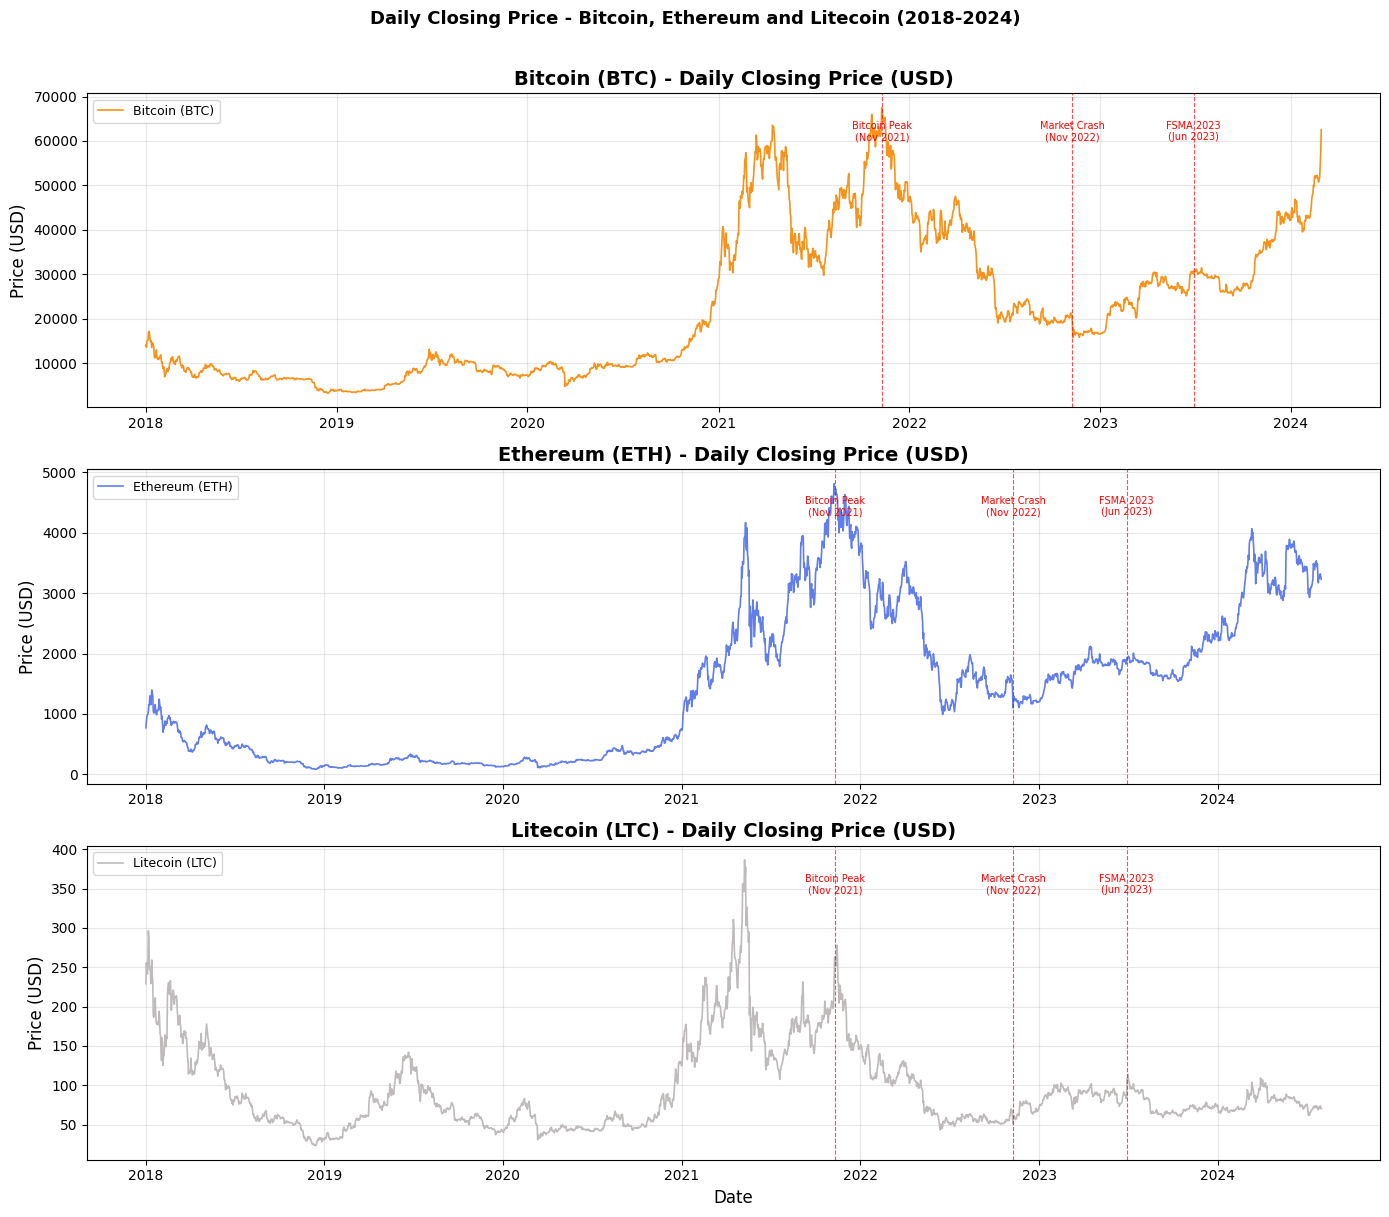

In [ ]:
# SECTION 6: FIGURE 1 - CLOSING PRICE TIME SERIES
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Key regulatory event dates
regulatory_dates = {
    'Bitcoin Peak\n(Nov 2021)': '2021-11-10',
    'Market Crash\n(Nov 2022)': '2022-11-09',
    'FSMA 2023\n(Jun 2023)': '2023-06-29'
}

colors = ['#F7931A', '#627EEA', '#BFBBBB']
assets = [('Bitcoin (BTC)', btc, colors[0]),
          ('Ethereum (ETH)', eth, colors[1]),
          ('Litecoin (LTC)', ltc, colors[2])]

for ax, (name, df, color) in zip(axes, assets):
    ax.plot(df['Date'], df['Close'], color=color, linewidth=1.2, label=name)
    for label, date in regulatory_dates.items():
        dt = pd.Timestamp(date)
        if dt >= df['Date'].min() and dt <= df['Date'].max():
            ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
            ax.text(dt, ax.get_ylim()[1] * 0.85, label,
                    fontsize=7, color='red', ha='center')
    ax.set_title(f'{name} - Daily Closing Price (USD)', fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

axes[2].set_xlabel('Date')
plt.suptitle('Daily Closing Price - Bitcoin, Ethereum and Litecoin (2018-2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

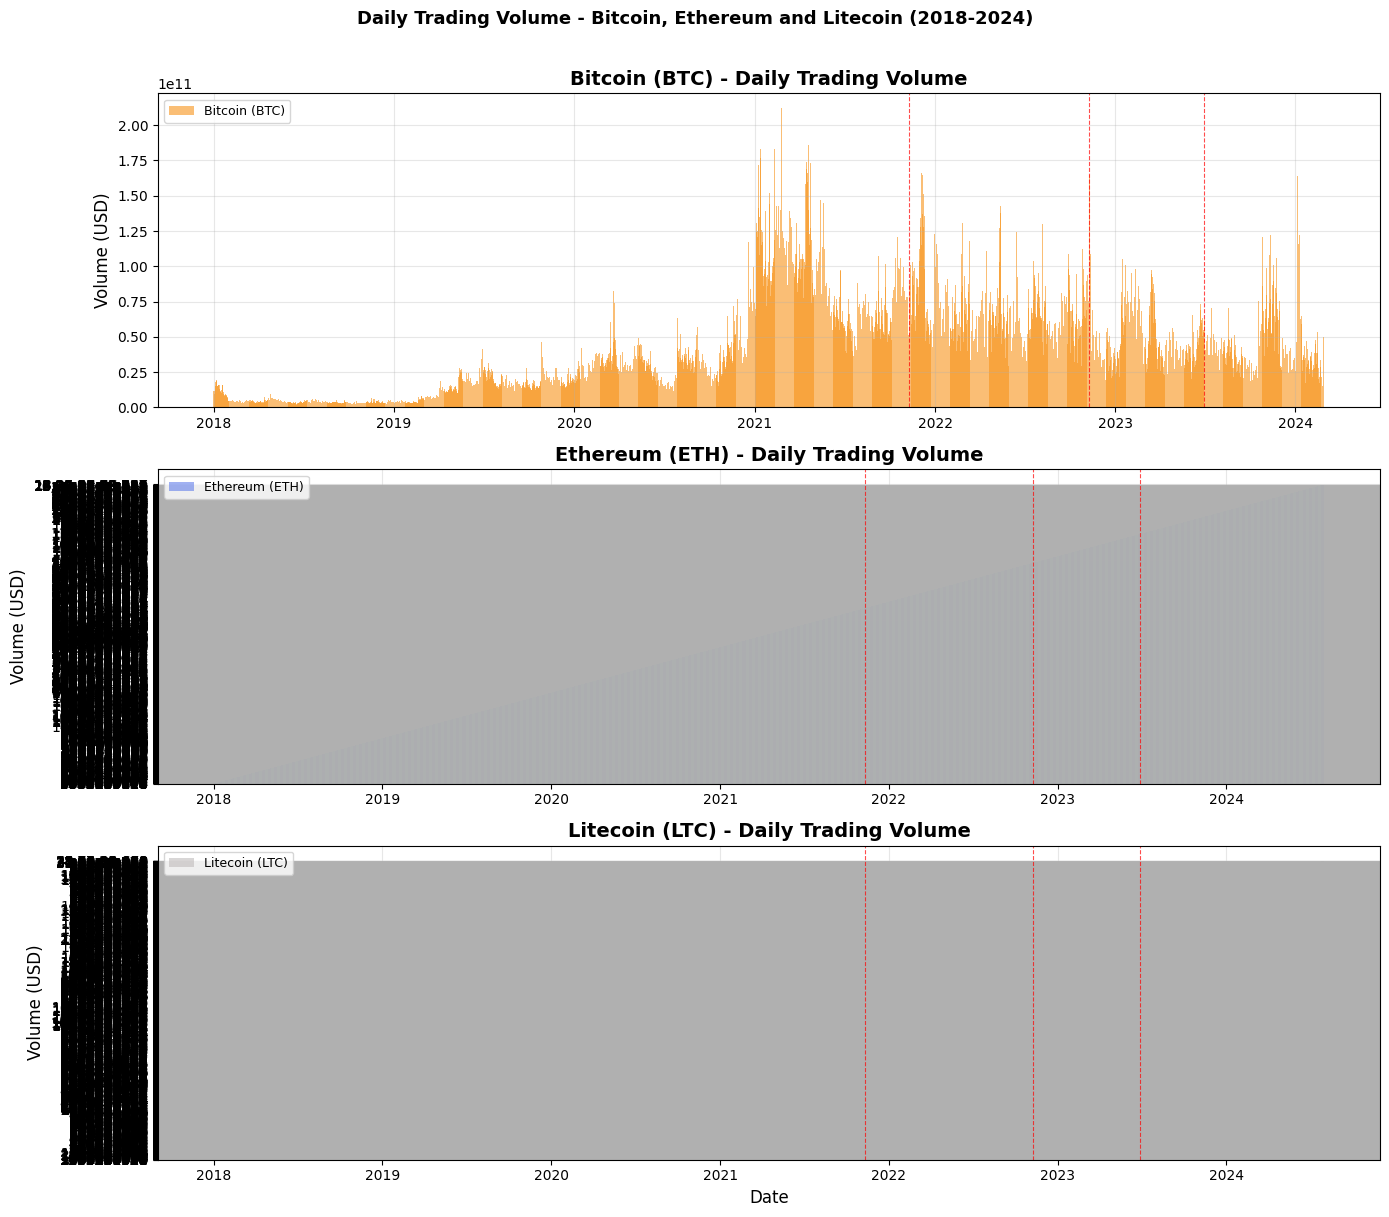

In [ ]:
# SECTION 7: FIGURE 2 - TRADING VOLUME TIME SERIES
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, (name, df, color) in zip(axes, assets):
    ax.bar(df['Date'], df['Volume'], color=color, alpha=0.6, width=1.5, label=name)
    for label, date in regulatory_dates.items():
        dt = pd.Timestamp(date)
        if dt >= df['Date'].min() and dt <= df['Date'].max():
            ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_title(f'{name} - Daily Trading Volume', fontweight='bold')
    ax.set_ylabel('Volume (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

axes[2].set_xlabel('Date')
plt.suptitle('Daily Trading Volume - Bitcoin, Ethereum and Litecoin (2018-2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


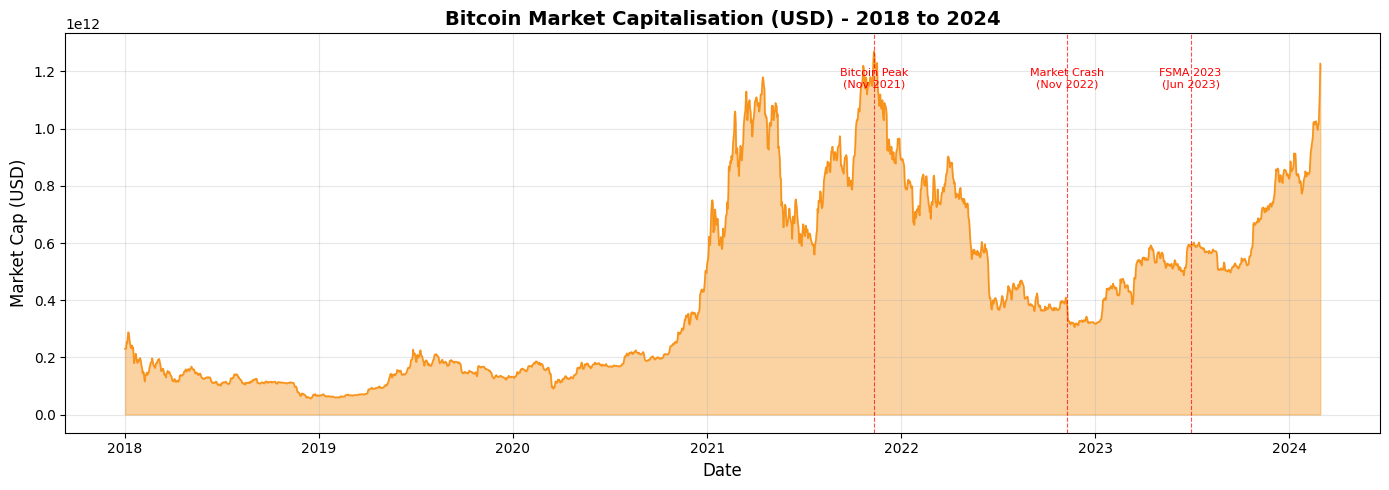

In [ ]:
# SECTION 8: FIGURE 3 - BITCOIN MARKET CAPITALISATION
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(btc['Date'], btc['Market Cap'], color='#F7931A', alpha=0.4)
ax.plot(btc['Date'], btc['Market Cap'], color='#F7931A', linewidth=1.2)

for label, date in regulatory_dates.items():
    dt = pd.Timestamp(date)
    ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(dt, btc['Market Cap'].max() * 0.9, label,
            fontsize=8, color='red', ha='center')

ax.set_title('Bitcoin Market Capitalisation (USD) - 2018 to 2024',
             fontweight='bold')
ax.set_ylabel('Market Cap (USD)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


TABLE 2: PEARSON CORRELATION MATRIX - DAILY CLOSING PRICES
(Overlapping period: 2018-01-01 to 2024-02-28, n=2250 days)
          Bitcoin  Ethereum  Litecoin
Bitcoin    1.0000    0.9263    0.6195
Ethereum   0.9263    1.0000    0.5855
Litecoin   0.6195    0.5855    1.0000


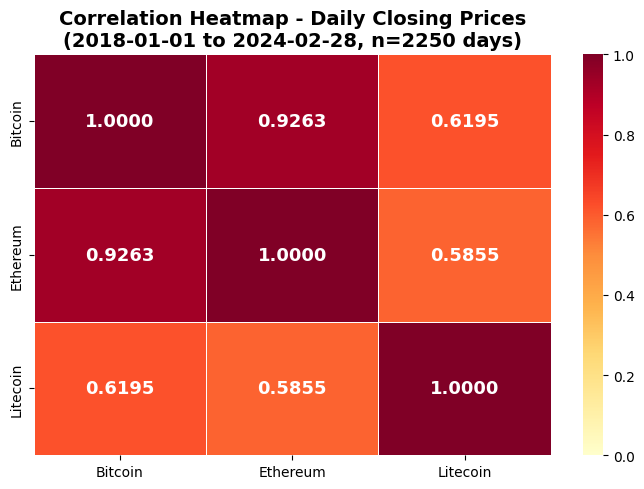

In [ ]:
# SECTION 9: CORRELATION ANALYSIS (TABLE 2)
# Merge on overlapping dates
merged = btc[['Date', 'Close']].merge(
    eth[['Date', 'Close']], on='Date', suffixes=('_btc', '_eth')
).merge(ltc[['Date', 'Close']], on='Date')
merged.rename(columns={'Close': 'Close_ltc'}, inplace=True)

corr_matrix = merged[['Close_btc', 'Close_eth', 'Close_ltc']].corr().round(4)
corr_matrix.index = ['Bitcoin', 'Ethereum', 'Litecoin']
corr_matrix.columns = ['Bitcoin', 'Ethereum', 'Litecoin']

print("\n" + "="*60)
print("TABLE 2: PEARSON CORRELATION MATRIX - DAILY CLOSING PRICES")
print(f"(Overlapping period: {merged['Date'].min().date()} to {merged['Date'].max().date()}, n={len(merged)} days)")
print("="*60)
print(corr_matrix.to_string())

# FIGURE 4 - CORRELATION HEATMAP
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('Correlation Heatmap - Daily Closing Prices\n'
             f'(2018-01-01 to 2024-02-28, n={len(merged)} days)',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# SECTION 11: VOLATILITY ANALYSIS - DAILY RETURNS (TABLE 3)
# Calculate daily log returns
btc['Log_Return'] = np.log(btc['Close'] / btc['Close'].shift(1))
eth['Log_Return'] = np.log(eth['Close'] / eth['Close'].shift(1))
ltc['Log_Return'] = np.log(ltc['Close'] / ltc['Close'].shift(1))

# Annualised volatility (standard deviation of log returns * sqrt(365))
btc_vol = btc['Log_Return'].std() * np.sqrt(365)
eth_vol = eth['Log_Return'].std() * np.sqrt(365)
ltc_vol = ltc['Log_Return'].std() * np.sqrt(365)

print("\n" + "="*60)
print("TABLE 3: VOLATILITY ANALYSIS - DAILY LOG RETURNS")
print("="*60)

vol_stats = pd.DataFrame({
    'Bitcoin (BTC)': [
        round(btc['Log_Return'].mean() * 100, 4),
        round(btc['Log_Return'].std() * 100, 4),
        round(btc['Log_Return'].min() * 100, 4),
        round(btc['Log_Return'].max() * 100, 4),
        round(btc_vol * 100, 2)
    ],
    'Ethereum (ETH)': [
        round(eth['Log_Return'].mean() * 100, 4),
        round(eth['Log_Return'].std() * 100, 4),
        round(eth['Log_Return'].min() * 100, 4),
        round(eth['Log_Return'].max() * 100, 4),
        round(eth_vol * 100, 2)
    ],
    'Litecoin (LTC)': [
        round(ltc['Log_Return'].mean() * 100, 4),
        round(ltc['Log_Return'].std() * 100, 4),
        round(ltc['Log_Return'].min() * 100, 4),
        round(ltc['Log_Return'].max() * 100, 4),
        round(ltc_vol * 100, 2)
    ]
}, index=['Mean Daily Return (%)', 'Std Dev (%)', 'Min Return (%)',
          'Max Return (%)', 'Annualised Volatility (%)'])

print(vol_stats.to_string())


TABLE 3: VOLATILITY ANALYSIS - DAILY LOG RETURNS
                           Bitcoin (BTC)  Ethereum (ETH)  Litecoin (LTC)
Mean Daily Return (%)            -0.0664          0.0595         -0.0492
Std Dev (%)                       3.7022          4.6321          4.9378
Min Return (%)                  -17.2829        -55.0732        -44.9062
Max Return (%)                   51.8084         23.0695         29.0594
Annualised Volatility (%)        70.7300         88.5000         94.3400


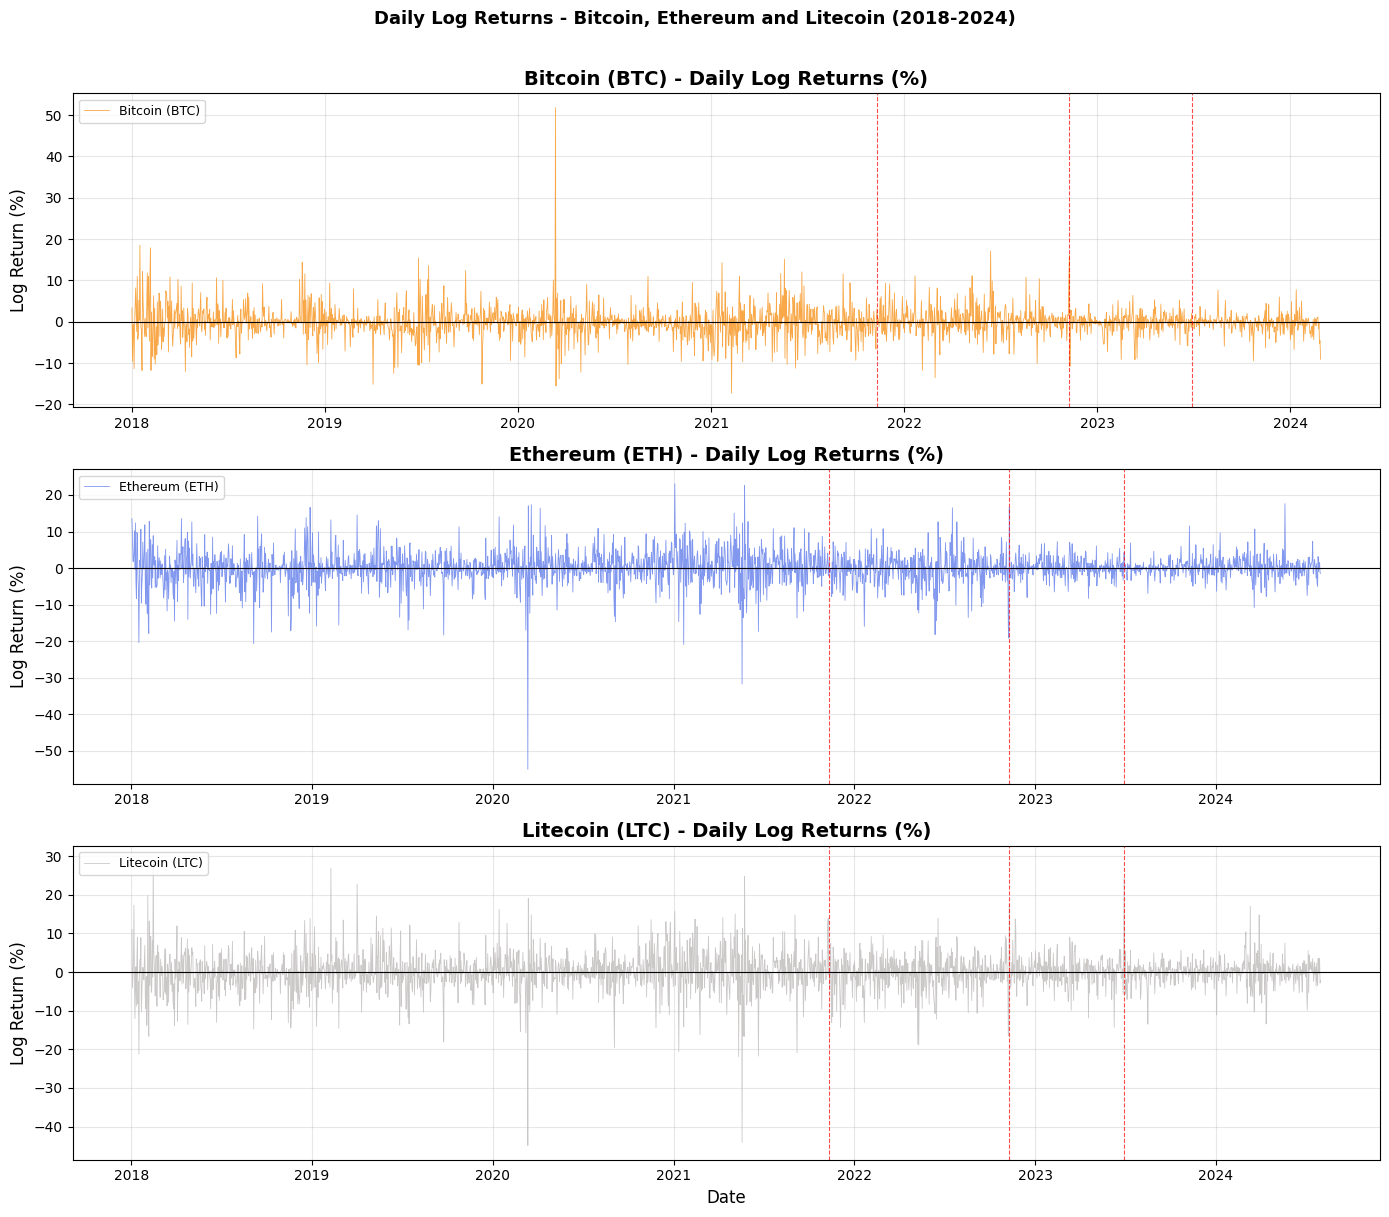

In [ ]:
# SECTION 12: FIGURE 5 - DAILY LOG RETURNS

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

return_colors = ['#F7931A', '#627EEA', '#BFBBBB']
return_assets = [('Bitcoin (BTC)', btc, return_colors[0]),
                 ('Ethereum (ETH)', eth, return_colors[1]),
                 ('Litecoin (LTC)', ltc, return_colors[2])]

for ax, (name, df, color) in zip(axes, return_assets):
    ax.plot(df['Date'], df['Log_Return'] * 100, color=color,
            linewidth=0.6, alpha=0.8, label=name)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
    for label, date in regulatory_dates.items():
        dt = pd.Timestamp(date)
        if dt >= df['Date'].min() and dt <= df['Date'].max():
            ax.axvline(x=dt, color='red', linestyle='--',
                       linewidth=0.8, alpha=0.7)
    ax.set_title(f'{name} - Daily Log Returns (%)', fontweight='bold')
    ax.set_ylabel('Log Return (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

axes[2].set_xlabel('Date')
plt.suptitle('Daily Log Returns - Bitcoin, Ethereum and Litecoin (2018-2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# SECTION 13: CGT SIMULATION - OBJECTIVE 2
# Simulates annual CGT liability for a hypothetical UK investor
# holding a fixed quantity of each cryptocurrency
# Based on HMRC disposal rules: each year-end disposal is taxed
# at CGT rates with annual exempt amounts applied
print("\n" + "="*60)
print("TABLE 4: SIMULATED ANNUAL CGT LIABILITY - UK INVESTOR")
print("Assumptions: 1 BTC | 10 ETH | 100 LTC purchased Jan 2018")
print("Annual disposal at year-end closing price")
print("CGT rate: 20% (higher rate taxpayer)")
print("="*60)

# Quantities held
BTC_QTY = 1
ETH_QTY = 10
LTC_QTY = 100

# Cost basis (Jan 2018 opening prices)
BTC_COST = float(btc[btc['Date'] == '2018-01-01']['Open'].values[0])
ETH_COST = float(eth[eth['Date'] == '2018-01-01']['Open'].values[0])
LTC_COST = float(ltc[ltc['Date'] == '2018-01-01']['Open'].values[0])

# Annual exempt amounts per HMRC
exempt_amounts = {
    2018: 11700, 2019: 12000, 2020: 12300, 2021: 12300,
    2022: 12300, 2023: 6000, 2024: 3000
}

# CGT rate for higher rate taxpayer
CGT_RATE = 0.20

cgt_results = []

for year in range(2018, 2025):
    # Get year-end closing prices
    year_end = f'{year}-12-31'
    btc_year = btc[btc['Date'].dt.year == year]
    eth_year = eth[eth['Date'].dt.year == year]
    ltc_year = ltc[ltc['Date'].dt.year == year]

    if len(btc_year) == 0:
        continue

    btc_price = float(btc_year['Close'].iloc[-1])
    eth_price = float(eth_year['Close'].iloc[-1]) if len(eth_year) > 0 else 0
    ltc_price = float(ltc_year['Close'].iloc[-1]) if len(ltc_year) > 0 else 0

    # Calculate gains
    btc_gain = (btc_price - BTC_COST) * BTC_QTY
    eth_gain = (eth_price - ETH_COST) * ETH_QTY
    ltc_gain = (ltc_price - LTC_COST) * LTC_QTY
    total_gain = btc_gain + eth_gain + ltc_gain

    # Apply annual exempt amount
    exempt = exempt_amounts.get(year, 3000)
    taxable_gain = max(0, total_gain - exempt)
    cgt_liability = taxable_gain * CGT_RATE

    cgt_results.append({
        'Tax Year': f'{year}/{str(year+1)[-2:]}',
        'BTC Close (USD)': round(btc_price, 2),
        'ETH Close (USD)': round(eth_price, 2),
        'LTC Close (USD)': round(ltc_price, 2),
        'Total Gain (USD)': round(total_gain, 2),
        'CGT Exempt (USD)': exempt,
        'Taxable Gain (USD)': round(taxable_gain, 2),
        'CGT Liability (USD)': round(cgt_liability, 2)
    })

cgt_df = pd.DataFrame(cgt_results)
print(cgt_df.to_string(index=False))


TABLE 4: SIMULATED ANNUAL CGT LIABILITY - UK INVESTOR
Assumptions: 1 BTC | 10 ETH | 100 LTC purchased Jan 2018
Annual disposal at year-end closing price
CGT rate: 20% (higher rate taxpayer)
Tax Year  BTC Close (USD)  ETH Close (USD)  LTC Close (USD)  Total Gain (USD)  CGT Exempt (USD)  Taxable Gain (USD)  CGT Liability (USD)
 2018/19         14033.57           133.37            30.47         -24906.12             11700                0.00                 0.00
 2019/20          3746.12           129.61            41.34         -34143.95             12000                0.00                 0.00
 2020/21          7202.62           737.80           124.69         -16270.50             12300                0.00                 0.00
 2021/22         28977.96          3682.63           146.51          37135.58             12300            24835.58              4967.12
 2022/23         46304.95          1196.77            70.00          21952.09             12300             9652.09         

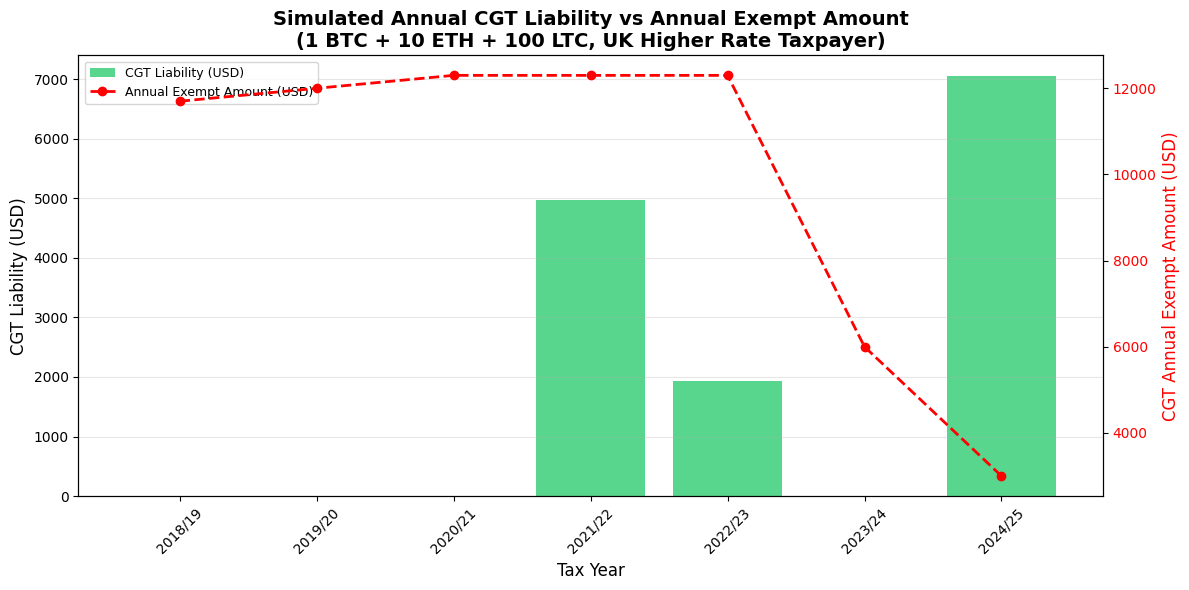

In [ ]:
# SECTION 14: FIGURE 6 - CGT LIABILITY OVER TIME
fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(cgt_df))
bars = ax1.bar(x, cgt_df['CGT Liability (USD)'],
               color=['#2ecc71' if v >= 0 else '#e74c3c'
                      for v in cgt_df['CGT Liability (USD)']],
               alpha=0.8, label='CGT Liability (USD)')

ax1.set_xlabel('Tax Year')
ax1.set_ylabel('CGT Liability (USD)', color='black')
ax1.set_xticks(x)
ax1.set_xticklabels(cgt_df['Tax Year'], rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

ax2 = ax1.twinx()
ax2.plot(x, cgt_df['CGT Exempt (USD)'], 'r--o',
         linewidth=2, markersize=6, label='Annual Exempt Amount (USD)')
ax2.set_ylabel('CGT Annual Exempt Amount (USD)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.title('Simulated Annual CGT Liability vs Annual Exempt Amount\n'
          '(1 BTC + 10 ETH + 100 LTC, UK Higher Rate Taxpayer)',
          fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# SECTION 15: REGULATORY EVENT IMPACT ANALYSIS - OBJECTIVE 3
# Examines price behaviour 30 days before and after key UK events
print("\n" + "="*60)
print("TABLE 5: PRICE IMPACT OF KEY UK REGULATORY EVENTS")
print("(Average closing price 30 days before vs 30 days after)")
print("="*60)

events = {
    'FSMA 2023 Royal Assent (29 Jun 2023)': '2023-06-29',
    'HMRC CGT Reduction (06 Apr 2023)': '2023-04-06',
    'Bitcoin Market Peak (10 Nov 2021)': '2021-11-10',
    'Crypto Market Crash (09 Nov 2022)': '2022-11-09'
}

event_results = []

for event_name, event_date in events.items():
    dt = pd.Timestamp(event_date)
    for asset_name, df in [('Bitcoin', btc), ('Ethereum', eth), ('Litecoin', ltc)]:
        before = df[(df['Date'] >= dt - pd.Timedelta(days=30)) &
                    (df['Date'] < dt)]['Close'].mean()
        after = df[(df['Date'] > dt) &
                   (df['Date'] <= dt + pd.Timedelta(days=30))]['Close'].mean()
        if pd.notna(before) and pd.notna(after):
            change_pct = ((after - before) / before) * 100
            event_results.append({
                'Event': event_name,
                'Asset': asset_name,
                'Avg Price Before (USD)': round(before, 2),
                'Avg Price After (USD)': round(after, 2),
                'Price Change (%)': round(change_pct, 2)
            })

event_df = pd.DataFrame(event_results)
print(event_df.to_string(index=False))


TABLE 5: PRICE IMPACT OF KEY UK REGULATORY EVENTS
(Average closing price 30 days before vs 30 days after)
                               Event    Asset  Avg Price Before (USD)  Avg Price After (USD)  Price Change (%)
FSMA 2023 Royal Assent (29 Jun 2023)  Bitcoin                27476.71               30157.47              9.76
FSMA 2023 Royal Assent (29 Jun 2023) Ethereum                 1818.36                1896.97              4.32
FSMA 2023 Royal Assent (29 Jun 2023) Litecoin                   85.07                  96.60             13.55
    HMRC CGT Reduction (06 Apr 2023)  Bitcoin                25850.29               28949.99             11.99
    HMRC CGT Reduction (06 Apr 2023) Ethereum                 1718.58                1927.18             12.14
    HMRC CGT Reduction (06 Apr 2023) Litecoin                   85.73                  91.07              6.24
   Bitcoin Market Peak (10 Nov 2021)  Bitcoin                61114.67               57211.93             -6.39
   Bi

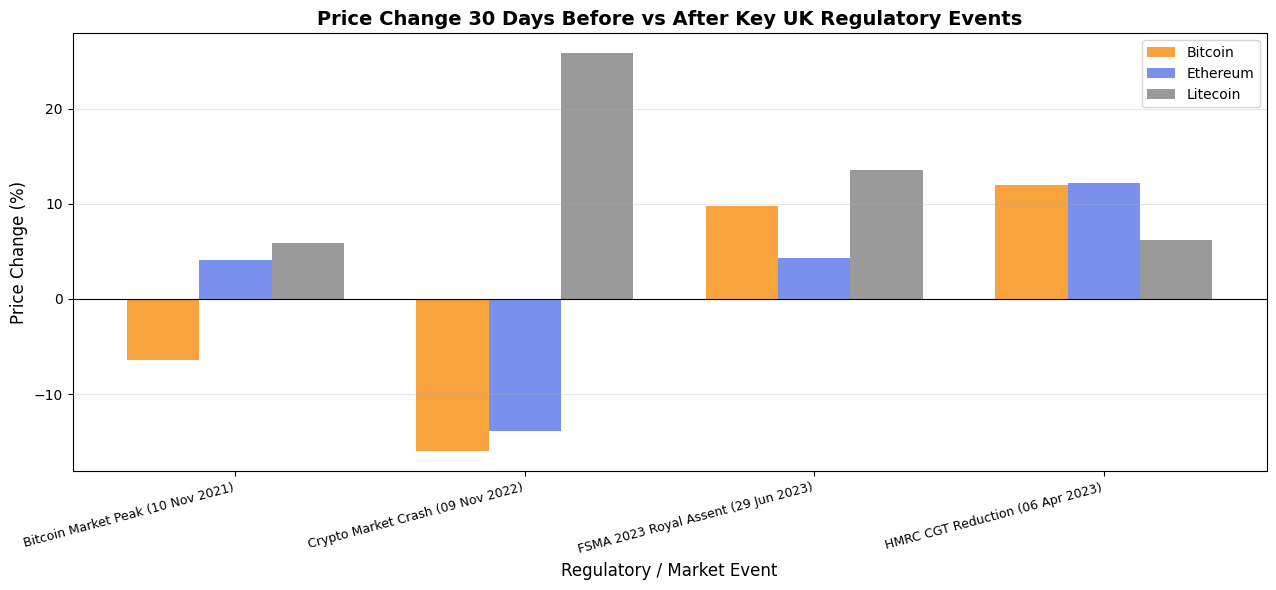

In [ ]:
# SECTION 16: FIGURE 7 - REGULATORY EVENT PRICE IMPACT
fig, ax = plt.subplots(figsize=(13, 6))

pivot = event_df.pivot(index='Event', columns='Asset', values='Price Change (%)')
x = np.arange(len(pivot.index))
width = 0.25

bars1 = ax.bar(x - width, pivot['Bitcoin'], width,
               label='Bitcoin', color='#F7931A', alpha=0.85)
bars2 = ax.bar(x, pivot['Ethereum'], width,
               label='Ethereum', color='#627EEA', alpha=0.85)
bars3 = ax.bar(x + width, pivot['Litecoin'], width,
               label='Litecoin', color='#888888', alpha=0.85)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Regulatory / Market Event')
ax.set_ylabel('Price Change (%)')
ax.set_title('Price Change 30 Days Before vs After Key UK Regulatory Events',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=15, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# SECTION 17: RISK AND OPPORTUNITY ANALYSIS - OBJECTIVE 4
# Rolling 30-day volatility and Sharpe Ratio
# Rolling 30-day volatility
btc['Rolling_Vol_30'] = btc['Log_Return'].rolling(window=30).std() * np.sqrt(365) * 100
eth['Rolling_Vol_30'] = eth['Log_Return'].rolling(window=30).std() * np.sqrt(365) * 100
ltc['Rolling_Vol_30'] = ltc['Log_Return'].rolling(window=30).std() * np.sqrt(365) * 100

# Sharpe Ratio (risk-free rate = 2% annual, approximate UK base rate average)
RISK_FREE_RATE = 0.02 / 365

btc_sharpe = (btc['Log_Return'].mean() - RISK_FREE_RATE) / btc['Log_Return'].std()
eth_sharpe = (eth['Log_Return'].mean() - RISK_FREE_RATE) / eth['Log_Return'].std()
ltc_sharpe = (ltc['Log_Return'].mean() - RISK_FREE_RATE) / ltc['Log_Return'].std()

print("\n" + "="*60)
print("TABLE 6: RISK AND RETURN SUMMARY - OBJECTIVE 4")
print("="*60)

risk_df = pd.DataFrame({
    'Metric': [
        'Annualised Volatility (%)',
        'Annualised Return (%)',
        'Sharpe Ratio (daily)',
        'Max Drawdown (%)',
        'Value at Risk 95% (daily %)'
    ],
    'Bitcoin': [
        round(btc_vol * 100, 2),
        round(btc['Log_Return'].mean() * 365 * 100, 2),
        round(btc_sharpe, 4),
        round(((btc['Close'] / btc['Close'].cummax()) - 1).min() * 100, 2),
        round(btc['Log_Return'].quantile(0.05) * 100, 4)
    ],
    'Ethereum': [
        round(eth_vol * 100, 2),
        round(eth['Log_Return'].mean() * 365 * 100, 2),
        round(eth_sharpe, 4),
        round(((eth['Close'] / eth['Close'].cummax()) - 1).min() * 100, 2),
        round(eth['Log_Return'].quantile(0.05) * 100, 4)
    ],
    'Litecoin': [
        round(ltc_vol * 100, 2),
        round(ltc['Log_Return'].mean() * 365 * 100, 2),
        round(ltc_sharpe, 4),
        round(((ltc['Close'] / ltc['Close'].cummax()) - 1).min() * 100, 2),
        round(ltc['Log_Return'].quantile(0.05) * 100, 4)
    ]
})
print(risk_df.to_string(index=False))



TABLE 6: RISK AND RETURN SUMMARY - OBJECTIVE 4
                     Metric  Bitcoin  Ethereum  Litecoin
  Annualised Volatility (%)  70.7300   88.5000   94.3400
      Annualised Return (%) -24.2400   21.7300  -17.9600
       Sharpe Ratio (daily)  -0.0194    0.0117   -0.0111
           Max Drawdown (%) -95.2000  -93.9600  -92.0900
Value at Risk 95% (daily %)  -5.6251   -7.2049   -7.9345


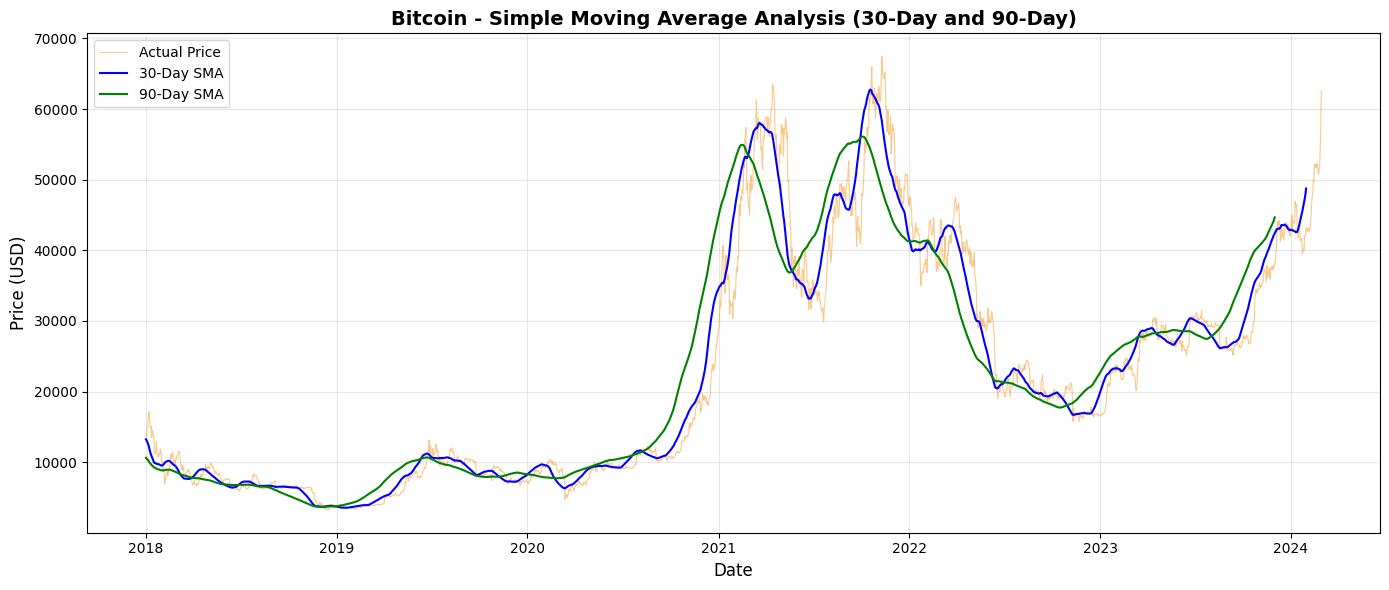


TABLE 7: SMA CROSSOVER SIGNALS - BITCOIN
(30-Day SMA crossing 90-Day SMA)
      Date        Close       SMA_30       SMA_90        Signal
2020-01-01  7202.624251  8266.149755  8292.555075 Bearish Cross
2019-11-07  9329.520807  8014.845135  7958.022847 Bullish Cross
2019-06-11  8000.570019 10462.610627 10486.905548 Bearish Cross
2018-12-26  3789.436638  3772.177427  3765.828904 Bullish Cross
2018-12-08  3424.127676  3691.970222  3692.447605 Bearish Cross
2018-12-02  4208.469723  3705.408594  3697.769413 Bullish Cross
2018-06-27  6103.030720  6761.218111  6785.850583 Bearish Cross
2018-05-30  7474.562016  6900.677391  6872.512417 Bullish Cross
2018-03-30  7178.058623  7785.340141  7799.744112 Bearish Cross
2018-03-07 10697.572290  8384.951663  8317.796010 Bullish Cross


In [ ]:
# SECTION: MOVING AVERAGE FORECASTING - BITCOIN (OBJECTIVE 1)
# 30-day and 90-day Simple Moving Averages
# Informed by Phung Duy et al. (2024) time series methodology
btc['SMA_30'] = btc['Close'].rolling(window=30).mean()
btc['SMA_90'] = btc['Close'].rolling(window=90).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(btc['Date'], btc['Close'],
        color='#F7931A', linewidth=0.8, alpha=0.5, label='Actual Price')
ax.plot(btc['Date'], btc['SMA_30'],
        color='blue', linewidth=1.5, label='30-Day SMA')
ax.plot(btc['Date'], btc['SMA_90'],
        color='green', linewidth=1.5, label='90-Day SMA')
ax.set_title('Bitcoin - Simple Moving Average Analysis (30-Day and 90-Day)',
             fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# SMA Crossover Signal Table
btc['Signal'] = 0
btc.loc[btc['SMA_30'] > btc['SMA_90'], 'Signal'] = 1
btc.loc[btc['SMA_30'] < btc['SMA_90'], 'Signal'] = -1

crossovers = btc[btc['Signal'].diff() != 0][['Date', 'Close', 'SMA_30', 'SMA_90', 'Signal']].dropna()
crossovers['Signal'] = crossovers['Signal'].map({1: 'Bullish Cross', -1: 'Bearish Cross'})

print("\nTABLE 7: SMA CROSSOVER SIGNALS - BITCOIN")
print("(30-Day SMA crossing 90-Day SMA)")
print(crossovers.tail(10).to_string(index=False))

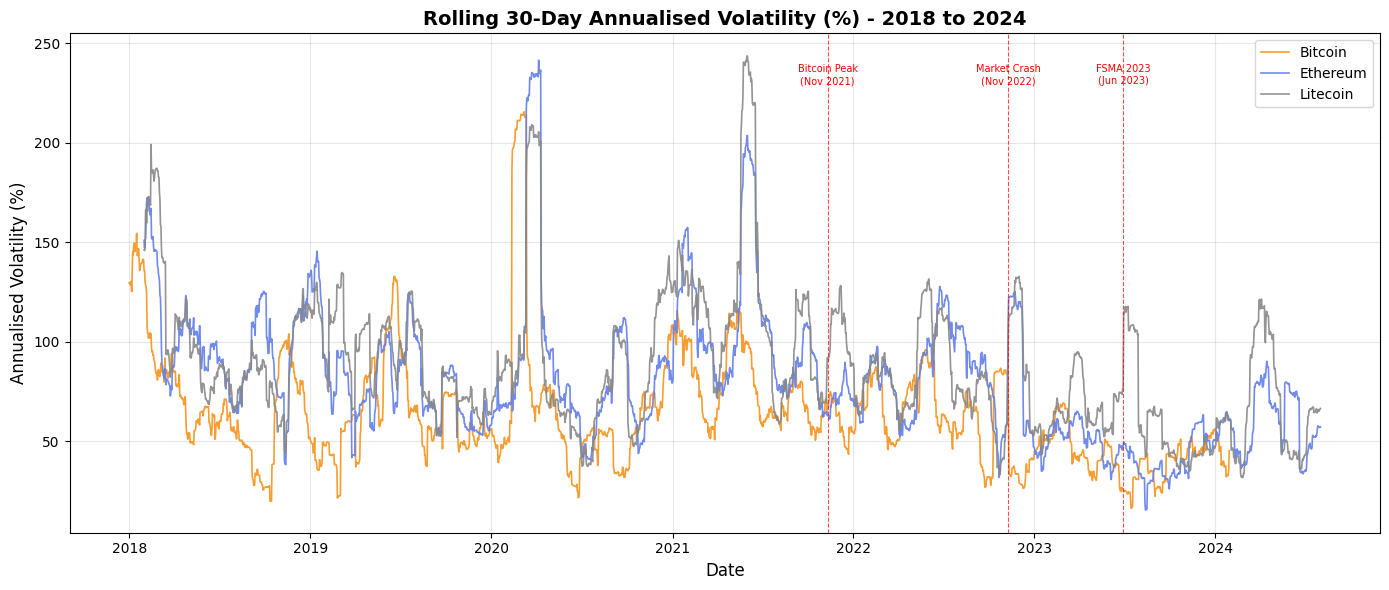

In [ ]:
# SECTION 18: FIGURE 8 - ROLLING 30-DAY VOLATILITY
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(btc['Date'], btc['Rolling_Vol_30'],
        color='#F7931A', linewidth=1.2, label='Bitcoin', alpha=0.9)
ax.plot(eth['Date'], eth['Rolling_Vol_30'],
        color='#627EEA', linewidth=1.2, label='Ethereum', alpha=0.9)
ax.plot(ltc['Date'], ltc['Rolling_Vol_30'],
        color='#888888', linewidth=1.2, label='Litecoin', alpha=0.9)

for label, date in regulatory_dates.items():
    dt = pd.Timestamp(date)
    ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(dt, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else 200,
            label, fontsize=7, color='red', ha='center')

ax.set_title('Rolling 30-Day Annualised Volatility (%) - 2018 to 2024',
             fontweight='bold')
ax.set_ylabel('Annualised Volatility (%)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

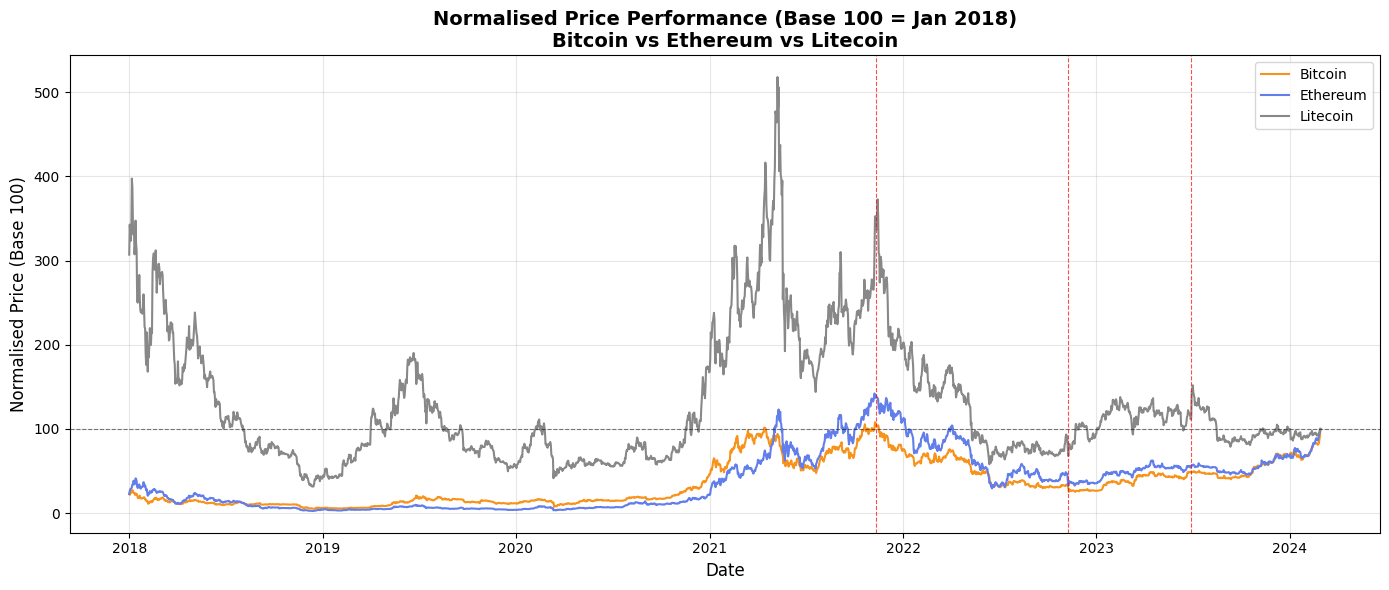

In [ ]:
# SECTION 19: FIGURE 9 - NORMALISED PRICE COMPARISON
# (Base 100 from Jan 2018 for direct comparison)
# Merge on common dates
common = btc[['Date', 'Close']].merge(
    eth[['Date', 'Close']], on='Date', suffixes=('_btc', '_eth')
).merge(ltc[['Date', 'Close']], on='Date')
common.rename(columns={'Close': 'Close_ltc'}, inplace=True)

# Normalise to base 100
common['BTC_norm'] = (common['Close_btc'] / common['Close_btc'].iloc[0]) * 100
common['ETH_norm'] = (common['Close_eth'] / common['Close_eth'].iloc[0]) * 100
common['LTC_norm'] = (common['Close_ltc'] / common['Close_ltc'].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(common['Date'], common['BTC_norm'],
        color='#F7931A', linewidth=1.5, label='Bitcoin')
ax.plot(common['Date'], common['ETH_norm'],
        color='#627EEA', linewidth=1.5, label='Ethereum')
ax.plot(common['Date'], common['LTC_norm'],
        color='#888888', linewidth=1.5, label='Litecoin')

ax.axhline(y=100, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

for label, date in regulatory_dates.items():
    dt = pd.Timestamp(date)
    ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_title('Normalised Price Performance (Base 100 = Jan 2018)\n'
             'Bitcoin vs Ethereum vs Litecoin', fontweight='bold')
ax.set_ylabel('Normalised Price (Base 100)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# SECTION 20: SUMMARY OF ALL OUTPUTS
print("\n" + "="*60)
print("IMPLEMENTATION COMPLETE - OUTPUTS GENERATED")
print("="*60)



IMPLEMENTATION COMPLETE - OUTPUTS GENERATED


In [ ]:
pip install pandas numpy statsmodels arch matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 20.4 MB/s eta 0:00:00


ADF p-value: 0.0


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

Best ARIMA(1,0,2) AIC=12266.25
                               SARIMAX Results                                
Dep. Variable:                log_ret   No. Observations:                 2249
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -6128.124
Date:                Wed, 15 Jul 2026   AIC                          12266.248
Time:                        10:01:17   BIC                          12294.839
Sample:                    01-02-2018   HQIC                         12276.684
                         - 02-28-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0677      0.088      0.770      0.441      -0.105       0.240
ar.L1          0.6457      0.183      3.536      0.000       0.288       1.004
ma.L1         -0.6983

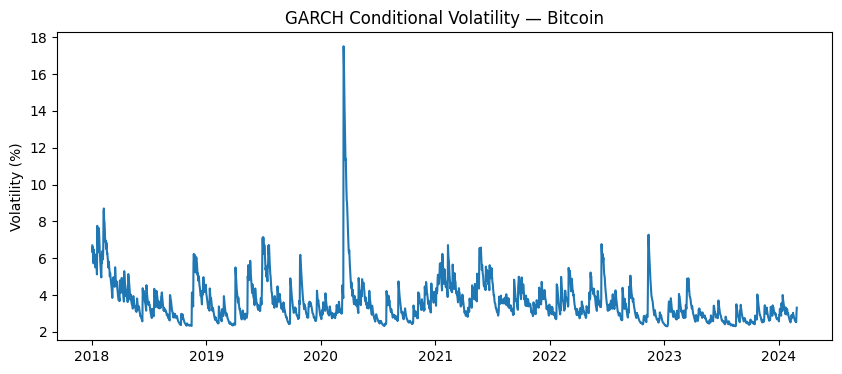

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

# ---- Load & clean (same idea as your project) ----
btc = pd.read_csv("/content/BITCOIN24.csv")
btc["Date"] = pd.to_datetime(btc["Date"], dayfirst=True)
btc = btc.sort_values("Date").dropna(subset=["Close"])

# Log returns (%) — usual input for GARCH
btc["log_ret"] = np.log(btc["Close"] / btc["Close"].shift(1)) * 100

# Set Date as index for the log returns Series to support forecasting
rets = btc.set_index("Date")["log_ret"].dropna()

# ---- Check stationarity (ADF test) ----
adf_stat, adf_p, *_ = adfuller(rets)
print("ADF p-value:", adf_p)  # p < 0.05 → returns are stationary

# ---- Step A: ARIMA on returns (mean model) ----
# Try small orders; pick lowest AIC
best = None
for p in range(0, 3):
    for q in range(0, 3):
        try:
            m = ARIMA(rets, order=(p, 0, q)).fit()
            if best is None or m.aic < best[0]:
                best = (m.aic, p, q, m)
        except Exception:
            pass

aic, p, q, arima_fit = best
print(f"Best ARIMA({p},0,{q}) AIC={aic:.2f}")
print(arima_fit.summary())

# ARIMA residuals → feed into GARCH
resid = arima_fit.resid.dropna()

# ---- Step B: GARCH(1,1) on residuals (volatility model) ----
garch = arch_model(resid, vol="Garch", p=1, q=1, mean="Zero", dist="normal")
garch_fit = garch.fit(disp="off")
print(garch_fit.summary())

# ---- Forecast next 5 days ----
arima_fc = arima_fit.forecast(5)
garch_fc = garch_fit.forecast(horizon=5)
print("Mean forecast (ARIMA):", arima_fc.values)
print("Volatility forecast (GARCH):", np.sqrt(garch_fc.variance.values[-1]))

# ---- Plot conditional volatility ----
cond_vol = garch_fit.conditional_volatility
plt.figure(figsize=(10, 4))
plt.plot(cond_vol.index, cond_vol.values)
plt.title("GARCH Conditional Volatility — Bitcoin")
plt.ylabel("Volatility (%)")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load & align dates
btc = pd.read_csv("BITCOIN24.csv")
eth = pd.read_csv("ETHEREUM.csv")
ltc = pd.read_csv("LITECOIN24.csv")

for df in (btc, eth):
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
    df.sort_values("Date", inplace=True)

btc = btc.dropna(subset=["Close"])
eth = eth.dropna(subset=["Close"])

# Log returns
btc["btc_ret"] = np.log(btc["Close"] / btc["Close"].shift(1))
eth["eth_ret"] = np.log(eth["Close"] / eth["Close"].shift(1))

data = (
    btc[["Date", "btc_ret"]]
    .merge(eth[["Date", "eth_ret"]], on="Date")
    .dropna()
)

# Regression: ETH_ret = a + b * BTC_ret
X = sm.add_constant(data["btc_ret"])   # adds intercept a
y = data["eth_ret"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                eth_ret   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     9.608
Date:                Wed, 15 Jul 2026   Prob (F-statistic):            0.00196
Time:                        10:23:22   Log-Likelihood:                 3687.1
No. Observations:                2249   AIC:                            -7370.
Df Residuals:                    2247   BIC:                            -7359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.001      0.719      0.4

/tmp/ipykernel_1418/2547922643.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eth["eth_ret"] = np.log(eth["Close"] / eth["Close"].shift(1))


In [ ]:
"""
Classification for crypto price direction & volatility forecasting
Works with BITCOIN24.csv / ETHEREUM.csv / LITECOIN24.csv style files
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# =========================================================
# 1) LOAD & CLEAN
# =========================================================
df = pd.read_csv("BITCOIN24.csv")  # change path if needed
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
df["Volume"] = pd.to_numeric(df.get("Volume", np.nan), errors="coerce")
df = df.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)

# =========================================================
# 2) FEATURE ENGINEERING
# =========================================================
# Daily log return (%)
df["ret"] = np.log(df["Close"] / df["Close"].shift(1)) * 100

# Rolling volatility (same idea as your 30-day risk window)
df["vol_30"] = df["ret"].rolling(30).std()

# Simple trend features (related to your SMA idea)
df["sma_30"] = df["Close"].rolling(30).mean()
df["sma_90"] = df["Close"].rolling(90).mean()
df["sma_spread"] = (df["sma_30"] - df["sma_90"]) / df["Close"] * 100

# Momentum / short history
df["ret_1"] = df["ret"].shift(1)
df["ret_2"] = df["ret"].shift(2)
df["ret_3"] = df["ret"].shift(3)
df["vol_lag"] = df["vol_30"].shift(1)

if "Volume" in df.columns:
    df["vol_change"] = df["Volume"].pct_change()
else:
    df["vol_change"] = 0.0

# =========================================================
# 3) CREATE CLASS LABELS (what we forecast)
# =========================================================
# A) Price direction class for NEXT day
#    1 = UP, 0 = DOWN
df["price_class"] = (df["ret"].shift(-1) > 0).astype(int)

# B) Volatility regime class for NEXT day
#    1 = HIGH vol, 0 = LOW vol
#    HIGH = next-day |return| above its rolling median
next_abs_ret = df["ret"].shift(-1).abs()
vol_threshold = next_abs_ret.rolling(30).median()
df["vol_class"] = (next_abs_ret > vol_threshold).astype(int)

# Drop rows with NaNs from rolling/shift
model_df = df.dropna().copy()

features = ["ret_1", "ret_2", "ret_3", "vol_lag", "sma_spread", "vol_change"]

# =========================================================
# 4) HELPER: train + evaluate one classification task
# =========================================================
def run_classifier(data, feature_cols, target_col, title):
    X = data[feature_cols]
    y = data[target_col]

    # Time-aware split: first 80% train, last 20% test (no shuffle)
    split = int(len(data) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # Two common classifiers
    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000)),
        ]),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=6,
            random_state=42,
            n_jobs=-1,
        ),
    }

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)
    print("Train size:", len(X_train), "| Test size:", len(X_test))
    print("Class balance in test:\n", y_test.value_counts(normalize=True).round(3))

    best_name, best_acc, best_pred, best_model = None, -1, None, None

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        print(f"\n--- {name} ---")
        print("Accuracy:", round(acc, 4))
        print(classification_report(y_test, pred, digits=3))

        if acc > best_acc:
            best_name, best_acc, best_pred, best_model = name, acc, pred, model

    # Confusion matrix for best model
    cm = confusion_matrix(y_test, best_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"{title}\nBest: {best_name} (Acc={best_acc:.3f})")


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

btc = pd.read_csv("BITCOIN24.csv")
btc["Date"] = pd.to_datetime(btc["Date"], dayfirst=True)
btc = btc.sort_values("Date").dropna(subset=["Close"])

# Log returns (%) — stationary series
btc["log_ret"] = np.log(btc["Close"] / btc["Close"].shift(1)) * 100
rets = btc["log_ret"].dropna()

print("ADF p-value (returns):", adfuller(rets)[1])  # should be < 0.05

# Best model from grid search on your data
model = ARIMA(rets, order=(1, 0, 2)).fit()
print(model.summary())

# 7-day return forecast
fc = model.get_forecast(7)
print(fc.predicted_mean)
print(fc.conf_int())

# Price forecast (use differencing d=1)
price_model = ARIMA(btc["Close"], order=(2, 1, 2)).fit()
print(price_model.get_forecast(7).predicted_mean)

ADF p-value (returns): 0.0


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                log_ret   No. Observations:                 2249
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -6128.124
Date:                Wed, 15 Jul 2026   AIC                          12266.248
Time:                        10:27:28   BIC                          12294.839
Sample:                             0   HQIC                         12276.684
                               - 2249                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0677      0.088      0.770      0.441      -0.105       0.240
ar.L1          0.6457      0.183      3.536      0.000       0.288       1.004
ma.L1         -0.6983      0.184     -3.803      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the

2250    62602.345656
2251    62771.024807
2252    62902.998567
2253    62920.842246
2254    62822.290648
2255    62675.966654
2256    62574.361550
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


ADF p-value: 2.1325474826161954e-27


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

Best ARIMA(1,0,2) AIC=14111.22
                               SARIMAX Results                                
Dep. Variable:                log_ret   No. Observations:                 2390
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -7050.612
Date:                Wed, 15 Jul 2026   AIC                          14111.224
Time:                        10:32:52   BIC                          14140.119
Sample:                    01-02-2018   HQIC                         14121.739
                         - 07-18-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0633      0.109      0.580      0.562      -0.150       0.277
ar.L1          0.6438      0.143      4.492      0.000       0.363       0.925
ma.L1         -0.6977

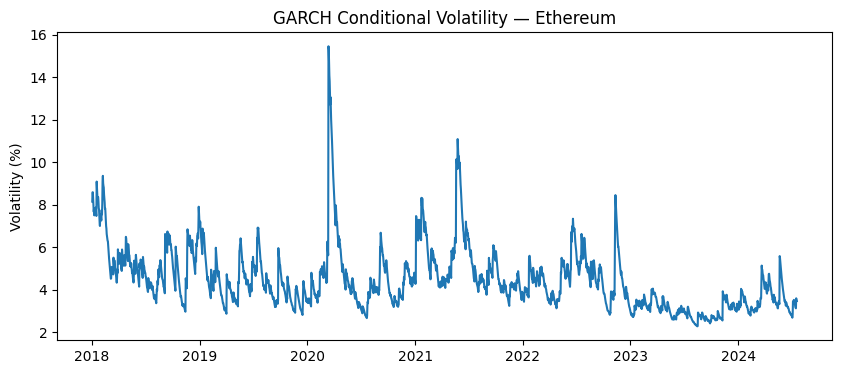

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

# ---- Load & clean (same idea as your project) ----
eth = pd.read_csv("/content/ETHEREUM.csv")
eth["Date"] = pd.to_datetime(eth["Date"], dayfirst=True, errors="coerce")
eth["Close"] = pd.to_numeric(eth["Close"], errors="coerce")
eth = eth.sort_values("Date").dropna(subset=["Close"]).reset_index(drop=True)

# Log returns (%) — usual input for GARCH
eth["log_ret"] = np.log(eth["Close"] / eth["Close"].shift(1)) * 100

# Set Date as index for the log returns Series to support forecasting
rets = eth.set_index("Date")["log_ret"].dropna()

# ---- Check stationarity (ADF test) ----
adf_stat, adf_p, *_ = adfuller(rets)
print("ADF p-value:", adf_p)  # p < 0.05 → returns are stationary

# ---- Step A: ARIMA on returns (mean model) ----
# Try small orders; pick lowest AIC
best = None
for p in range(0, 3):
    for q in range(0, 3):
        try:
            m = ARIMA(rets, order=(p, 0, q)).fit()
            if best is None or m.aic < best[0]:
                best = (m.aic, p, q, m)
        except Exception:
            pass

aic, p, q, arima_fit = best
print(f"Best ARIMA({p},0,{q}) AIC={aic:.2f}")
print(arima_fit.summary())

# ARIMA residuals → feed into GARCH
resid = arima_fit.resid.dropna()

# ---- Step B: GARCH(1,1) on residuals (volatility model) ----
garch = arch_model(resid, vol="Garch", p=1, q=1, mean="Zero", dist="normal")
garch_fit = garch.fit(disp="off")
print(garch_fit.summary())

# ---- Forecast next 5 days ----
arima_fc = arima_fit.forecast(5)
garch_fc = garch_fit.forecast(horizon=5)
print("Mean forecast (ARIMA):", arima_fc.values)
print("Volatility forecast (GARCH):", np.sqrt(garch_fc.variance.values[-1]))

# ---- Plot conditional volatility ----
cond_vol = garch_fit.conditional_volatility
plt.figure(figsize=(10, 4))
plt.plot(cond_vol.index, cond_vol.values)
plt.title("GARCH Conditional Volatility — Ethereum")
plt.ylabel("Volatility (%)")
plt.show()

ADF p-value: 2.6854471865828553e-30


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

Best ARIMA(2,0,2) AIC=14489.52
                               SARIMAX Results                                
Dep. Variable:                log_ret   No. Observations:                 2403
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -7238.759
Date:                Wed, 15 Jul 2026   AIC                          14489.519
Time:                        10:38:23   BIC                          14524.226
Sample:                    01-02-2018   HQIC                         14502.144
                         - 07-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0494      0.101     -0.488      0.626      -0.248       0.149
ar.L1         -1.8250      0.058    -31.236      0.000      -1.939      -1.710
ar.L2         -0.9045

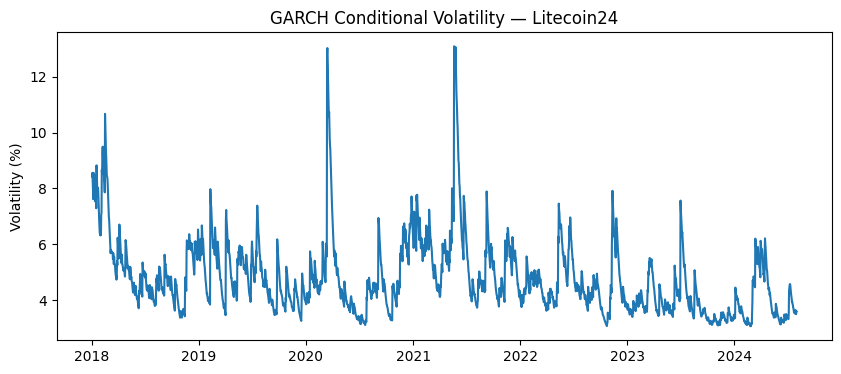

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

# ---- Load & clean (same idea as your project) ----
ltc = pd.read_csv("/content/LITECOIN24.csv")
ltc["Date"] = pd.to_datetime(ltc["Date"], dayfirst=True, errors="coerce")
ltc["Close"] = pd.to_numeric(ltc["Close"], errors="coerce")
ltc = ltc.sort_values("Date").dropna(subset=["Close"]).reset_index(drop=True)

# Log returns (%) — usual input for GARCH
ltc["log_ret"] = np.log(ltc["Close"] / ltc["Close"].shift(1)) * 100

# Set Date as index for the log returns Series to support forecasting
rets = ltc.set_index("Date")["log_ret"].dropna()

# ---- Check stationarity (ADF test) ----
adf_stat, adf_p, *_ = adfuller(rets)
print("ADF p-value:", adf_p)  # p < 0.05 → returns are stationary

# ---- Step A: ARIMA on returns (mean model) ----
# Try small orders; pick lowest AIC
best = None
for p in range(0, 3):
    for q in range(0, 3):
        try:
            m = ARIMA(rets, order=(p, 0, q)).fit()
            if best is None or m.aic < best[0]:
                best = (m.aic, p, q, m)
        except Exception:
            pass

aic, p, q, arima_fit = best
print(f"Best ARIMA({p},0,{q}) AIC={aic:.2f}")
print(arima_fit.summary())

# ARIMA residuals → feed into GARCH
resid = arima_fit.resid.dropna()

# ---- Step B: GARCH(1,1) on residuals (volatility model) ----
garch = arch_model(resid, vol="Garch", p=1, q=1, mean="Zero", dist="normal")
garch_fit = garch.fit(disp="off")
print(garch_fit.summary())

# ---- Forecast next 5 days ----
arima_fc = arima_fit.forecast(5)
garch_fc = garch_fit.forecast(horizon=5)
print("Mean forecast (ARIMA):", arima_fc.values)
print("Volatility forecast (GARCH):", np.sqrt(garch_fc.variance.values[-1]))

# ---- Plot conditional volatility ----
cond_vol = garch_fit.conditional_volatility
plt.figure(figsize=(10, 4))
plt.plot(cond_vol.index, cond_vol.values)
plt.title("GARCH Conditional Volatility — Litecoin24")
plt.ylabel("Volatility (%)")
plt.show()